In [42]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [43]:
import pandas as pd
from pathlib import Path

DATA_PATH = r"C:\Data-Scientist-Portfolio\Customer _Churn_ Prediction _System\data\customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [44]:
# =========================
# BASIC INFORMATION
# =========================

print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [45]:
# =========================
# FIX DATA TYPES
# =========================

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [46]:
# =========================
# HANDLE MISSING VALUES
# =========================

missing_values = df.isnull().sum()

print(missing_values)

# Fill missing TotalCharges
df['TotalCharges'].fillna(
    df['MonthlyCharges'],
    inplace=True
)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


C:\Users\91600\AppData\Local\Temp\ipykernel_13592\335128979.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


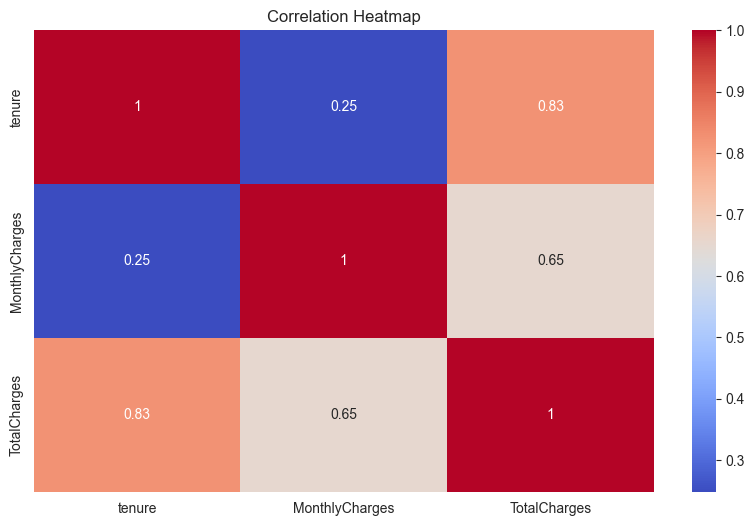

In [47]:
# =========================
# NUMERICAL CORRELATION
# =========================

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

corr_matrix = df[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

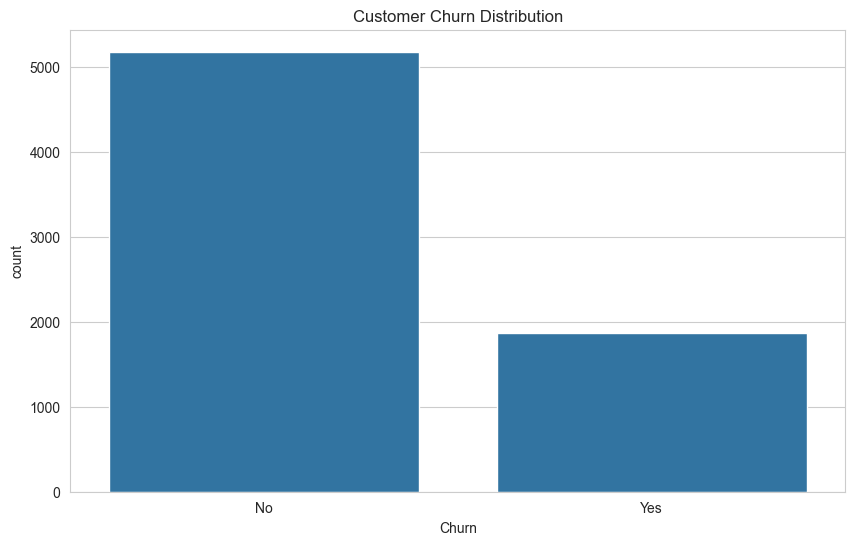

In [48]:
# =========================
# CHURN DISTRIBUTION
# =========================

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

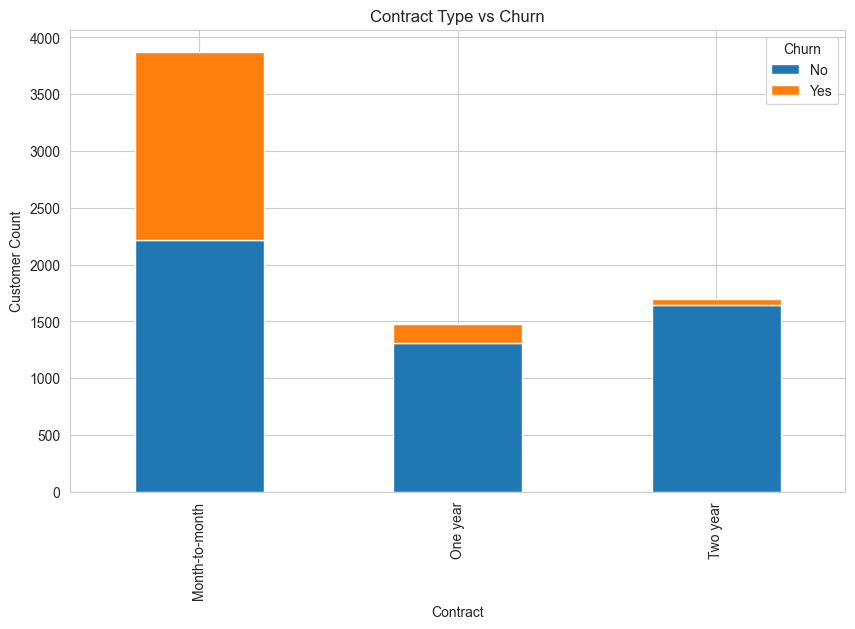

In [49]:
# =========================
# CONTRACT TYPE VS CHURN
# =========================

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn']
)

contract_churn.plot(
    kind='bar',
    stacked=True
)

plt.title("Contract Type vs Churn")
plt.ylabel("Customer Count")
plt.show()

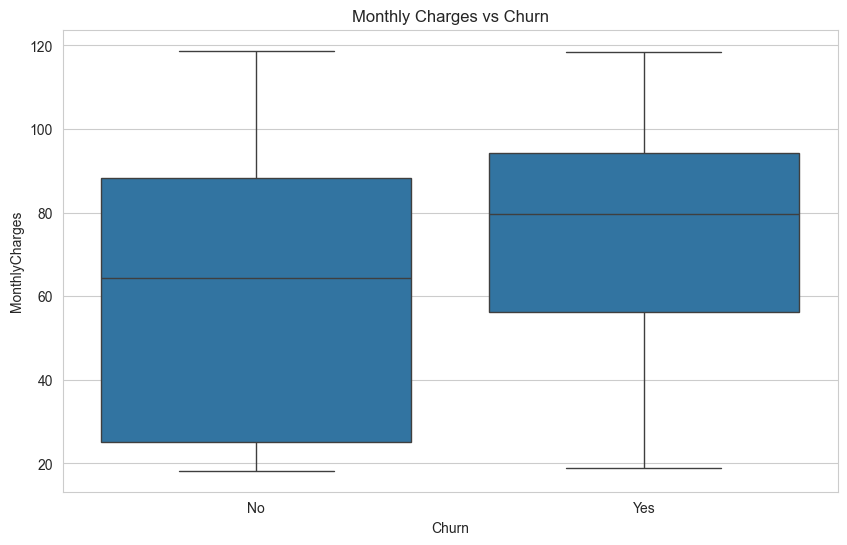

In [50]:
# =========================
# MONTHLY CHARGES ANALYSIS
# =========================

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

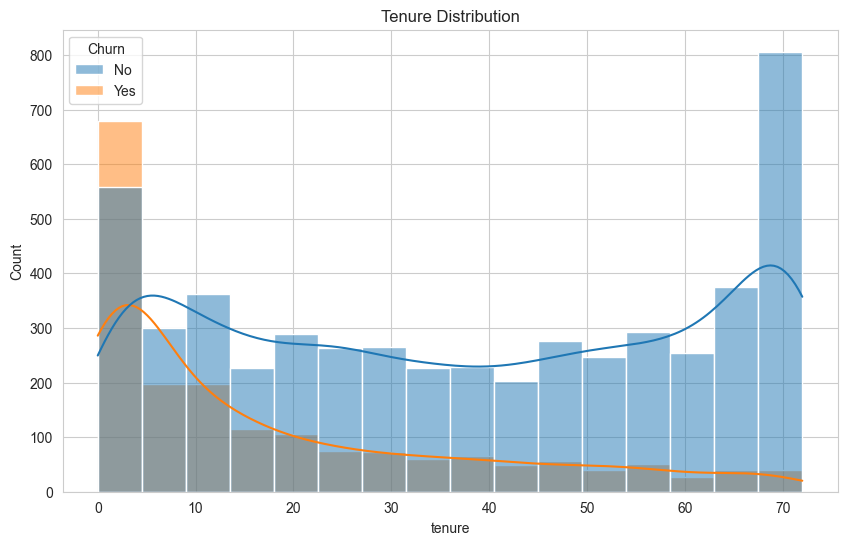

In [51]:
# =========================
# TENURE ANALYSIS
# =========================

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True
)

plt.title("Tenure Distribution")
plt.show()

In [52]:
# =========================
# BUSINESS INSIGHTS
# =========================

month_to_month_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)

print(month_to_month_churn)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


In [53]:
# =========================
# SAVE FIGURES
# =========================

OUTPUT_PATH = Path("outputs/plots")

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUTPUT_PATH / "churn_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 1000x600 with 0 Axes>

In [54]:
plt.savefig(
    "outputs/churn_analysis.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 1000x600 with 0 Axes>

In [55]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape